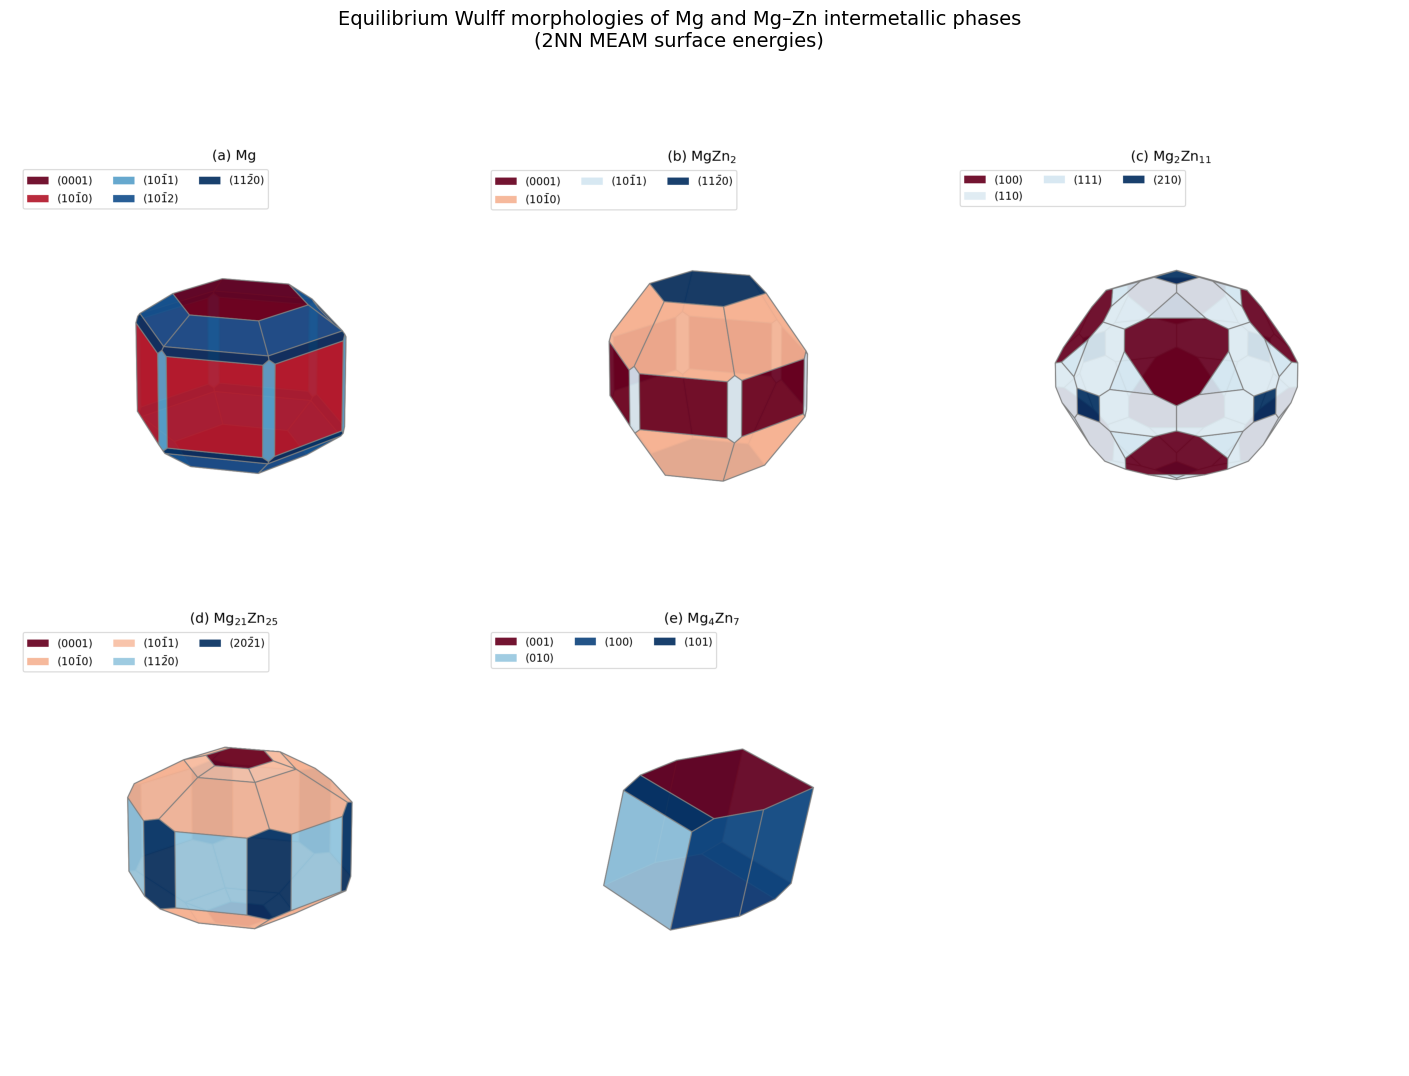

Saved: wulff_all_phases.pdf / .png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core import Lattice
import io

lattice_mg       = Lattice.hexagonal(3.20906, 5.19691)
lattice_mgzn2    = Lattice.hexagonal(5.33501, 8.67676)
lattice_mg2zn11  = Lattice.cubic(8.710)
lattice_mg21zn25 = Lattice.hexagonal(26.121, 8.788)
lattice_mg4zn7   = Lattice([[26.3536, 0,        0      ],
                             [0,       5.33657,  0      ],
                             [-3.12791, 0,       14.1091]])

data = [
    (
        lattice_mg,
        [(0,0,1), (1,0,0), (1,0,1), (1,0,2), (1,1,0)],
        [0.6769,  0.6896,  0.7989,  0.7915,  0.7711],
        r'(a) Mg',
        20, 45,
        [r'$(0001)$', r'$(10\bar{1}0)$', r'$(10\bar{1}1)$',
         r'$(10\bar{1}2)$', r'$(11\bar{2}0)$'],
    ),
    (
        lattice_mgzn2,
        [(0,0,1), (1,0,0), (1,0,1), (1,1,0)],
        [0.7304,  0.6165,  0.6535,  0.6839],
        r'(b) MgZn$_2$',
        20, 45,
        [r'$(0001)$', r'$(10\bar{1}0)$', r'$(10\bar{1}1)$', r'$(11\bar{2}0)$'],
    ),
    (
        lattice_mg2zn11,
        [(1,0,0), (1,1,0), (1,1,1), (2,1,0), (2,1,1)],
        [0.6271,  0.6320,  0.5593,  0.5975,  0.5991],
        r'(c) Mg$_2$Zn$_{11}$',
        20, 45,
        [r'$(100)$', r'$(110)$', r'$(111)$', r'$(210)$', r'$(211)$'],
    ),
    (
        lattice_mg21zn25,
        [(0,0,1), (1,0,0), (1,0,1), (1,1,0), (2,0,1)],
        [0.5946,  0.6451,  0.6200,  0.6676,  0.6184],
        r'(d) Mg$_{21}$Zn$_{25}$',
        20, 45,
        [r'$(0001)$', r'$(10\bar{1}0)$', r'$(10\bar{1}1)$',
         r'$(11\bar{2}0)$', r'$(20\bar{2}1)$'],
    ),
    (
        lattice_mg4zn7,
        [(0,0,1), (0,1,0), (1,0,0), (1,0,1), (1,1,0)],
        [0.5657,  1.3226,  0.6268,  0.6543,  0.6506],
        r'(e) Mg$_4$Zn$_7$',
        25, 55,
        [r'$(001)$', r'$(010)$', r'$(100)$', r'$(101)$', r'$(110)$'],
    ),
]

buffers = []
for (lattice, miller, gamma, title, elev, azim, leg_labels) in data:
    wulff = WulffShape(lattice, miller, gamma)
    ax = wulff.get_plot(
        color_set='RdBu',
        legend_on=True,
        alpha=0.92,
    )
    fig_tmp = ax.get_figure()
    fig_tmp.set_size_inches(6, 6)
    ax.view_init(elev=elev, azim=azim)

    # Fix legend labels to correct notation
    legend = ax.get_legend()
    if legend is not None:
        for text, label in zip(legend.get_texts(), leg_labels):
            text.set_text(label)
        legend.set_bbox_to_anchor((0.0, 1.0))
        legend.set_loc('upper left')

    ax.set_title(title, fontsize=13, pad=4, fontweight='normal')
    ax.set_box_aspect([1, 1, 0.85])
    ax.set_axis_off()
    plt.tight_layout(pad=0.5)

    buf = io.BytesIO()
    fig_tmp.savefig(buf, format='png', dpi=200, bbox_inches='tight',
                    facecolor='white')
    buf.seek(0)
    buffers.append(buf)
    plt.close(fig_tmp)

# ── Step 2: assemble 3x2 panel (5 plots + 1 empty) ───────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('white')

for i, (ax, buf) in enumerate(zip(axes.flat, buffers)):
    img = mpimg.imread(buf)
    ax.imshow(img)
    ax.set_axis_off()

# Hide the unused sixth panel
axes.flat[5].set_axis_off()

plt.subplots_adjust(hspace=0.0, wspace=0.02)
fig.suptitle(
    'Equilibrium Wulff morphologies of Mg and Mg\u2013Zn intermetallic phases\n'
    '(2NN MEAM surface energies)',
    fontsize=14,
    y=0.99,
)

fig.savefig('wulff_all_phases.pdf', bbox_inches='tight', dpi=300)
fig.savefig('wulff_all_phases.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: wulff_all_phases.pdf / .png")